# 🎯 **Reinforcement Learning: Complete Guide & Implementation**

## 🌟 **Introduction**

**Reinforcement Learning (RL)** is a paradigm of machine learning where agents learn optimal behavior through trial-and-error interactions with an environment. Unlike supervised learning, RL agents must discover which actions yield the most reward through exploration, making it particularly suitable for sequential decision-making problems.

### 🎓 **Learning Objectives**

By the end of this notebook, you will:

1. **Master RL fundamentals** - MDPs, Bellman equations, exploration vs exploitation
2. **Implement classical algorithms** - Q-Learning, SARSA, Policy/Value Iteration
3. **Understand deep RL** - DQN, Policy Gradients, Actor-Critic methods
4. **Apply modern techniques** - PPO, SAC, DDPG for continuous control
5. **Analyze performance** - Sample efficiency, convergence, stability
6. **Build real applications** - Game playing, robotics, autonomous systems

### 🗺️ **Notebook Structure**

- **Part I**: Mathematical Foundations & Core Concepts
- **Part II**: Tabular Methods (Q-Learning, SARSA, Dynamic Programming)
- **Part III**: Deep RL Revolution (DQN family, Function Approximation)
- **Part IV**: Policy Gradient Methods (REINFORCE, Actor-Critic, PPO)
- **Part V**: Advanced Algorithms (DDPG, SAC, Multi-Agent RL)
- **Part VI**: Real-World Applications & Case Studies

---

## 📊 **RL Algorithm Taxonomy**

| **Category** | **Algorithm** | **Type** | **Action Space** | **Best For** |
|-------------|-------------|----------|-----------------|--------------|
| **Tabular** | Q-Learning | Off-Policy | Discrete | Small state spaces |
| **Tabular** | SARSA | On-Policy | Discrete | Safe exploration |
| **Deep RL** | DQN | Off-Policy | Discrete | Atari games, discrete control |
| **Deep RL** | Double DQN | Off-Policy | Discrete | Reduced overestimation bias |
| **Policy Gradient** | REINFORCE | On-Policy | Both | Simple policy optimization |
| **Actor-Critic** | A3C | On-Policy | Both | Parallel training |
| **Actor-Critic** | PPO | On-Policy | Both | Stable, sample efficient |
| **Actor-Critic** | SAC | Off-Policy | Continuous | Continuous control, robustness |
| **Deterministic** | DDPG | Off-Policy | Continuous | Continuous control tasks |

---

## 🧭 **Key RL Concepts**

### **🎮 The RL Problem**
- **Agent**: The decision maker (e.g., game player, robot)
- **Environment**: The world the agent interacts with
- **State (s)**: Current situation/observation
- **Action (a)**: Decision/move the agent can make
- **Reward (r)**: Immediate feedback signal
- **Policy (π)**: Strategy for action selection

### **🎯 The Goal**
Maximize expected cumulative reward (return):
$$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

Where $\gamma \in [0,1]$ is the discount factor.

---

*"The reward is enough." - Rich Sutton*

*Reinforcement learning is not just a tool—it's a framework for understanding how intelligent behavior emerges from interaction with the world.*

In [ ]:
# 📦 SETUP & IMPORTS

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical, Normal
import gym
import random
from collections import deque, namedtuple
import pandas as pd
from typing import Dict, List, Tuple, Optional, Union
import warnings
from IPython.display import HTML, clear_output
import base64
from io import BytesIO
warnings.filterwarnings('ignore')

# Enhanced plotting setup
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("🎯 Reinforcement Learning: Complete Guide")
print("=" * 50)
print(f"📦 NumPy version: {np.__version__}")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎮 Gym version: {gym.__version__}")
print(f"🎨 Matplotlib/Seaborn ready")
print(f"⚙️  Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"🔢 Random seeds set for reproducibility")
print("🚀 Ready to explore reinforcement learning!")

In [ ]:
# 🎨 COMPREHENSIVE RL UTILITIES & ENVIRONMENTS

class RLVisualizer:
    """Advanced visualization tools for reinforcement learning"""
    
    def __init__(self):
        self.colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    def plot_learning_curves(self, results: Dict[str, List[float]], 
                           title: str = "Learning Curves", 
                           xlabel: str = "Episode", 
                           ylabel: str = "Reward",
                           window: int = 100):
        """Plot learning curves with smoothing"""
        plt.figure(figsize=(15, 6))
        
        # Raw and smoothed curves
        plt.subplot(1, 2, 1)
        for i, (name, rewards) in enumerate(results.items()):
            plt.plot(rewards, alpha=0.3, color=self.colors[i % len(self.colors)])
            # Moving average smoothing
            if len(rewards) > window:
                smoothed = pd.Series(rewards).rolling(window).mean()
                plt.plot(smoothed, label=name, linewidth=2, 
                        color=self.colors[i % len(self.colors)])
        
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(f'{title} (Smoothed)')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Box plots for performance comparison
        plt.subplot(1, 2, 2)
        data_for_box = []
        labels = []
        for name, rewards in results.items():
            # Take last 100 episodes for comparison
            data_for_box.append(rewards[-100:] if len(rewards) > 100 else rewards)
            labels.append(name)
        
        plt.boxplot(data_for_box, labels=labels)
        plt.ylabel(ylabel)
        plt.title('Performance Distribution (Final 100 Episodes)')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
    
    def plot_value_function(self, V: np.ndarray, title: str = "Value Function"):
        """Visualize value function as heatmap"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(V, annot=True, cmap='viridis', cbar=True, 
                   fmt='.2f', square=True)
        plt.title(title)
        plt.xlabel('Column')
        plt.ylabel('Row')
        plt.show()
    
    def plot_policy(self, policy: np.ndarray, title: str = "Policy"):
        """Visualize policy with arrows"""
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # Action arrows: 0=Up, 1=Right, 2=Down, 3=Left
        arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
        
        for i in range(policy.shape[0]):
            for j in range(policy.shape[1]):
                if isinstance(policy[i, j], (int, np.integer)):
                    ax.text(j, i, arrows.get(policy[i, j], '?'), 
                           ha='center', va='center', fontsize=20)
                else:
                    # For stochastic policies, show most likely action
                    best_action = np.argmax(policy[i, j])
                    ax.text(j, i, arrows.get(best_action, '?'), 
                           ha='center', va='center', fontsize=20)
        
        ax.set_xlim(-0.5, policy.shape[1] - 0.5)
        ax.set_ylim(-0.5, policy.shape[0] - 0.5)
        ax.set_xticks(range(policy.shape[1]))
        ax.set_yticks(range(policy.shape[0]))
        ax.grid(True)
        ax.set_title(title)
        plt.show()
    
    def plot_q_values(self, Q: np.ndarray, state: Tuple[int, int], 
                     title: str = "Q-Values"):
        """Plot Q-values for a specific state"""
        actions = ['Up', 'Right', 'Down', 'Left']
        q_vals = Q[state[0], state[1], :]
        
        plt.figure(figsize=(8, 6))
        bars = plt.bar(actions, q_vals, color=self.colors[:len(actions)])
        plt.title(f'{title} for State {state}')
        plt.ylabel('Q-Value')
        plt.xlabel('Action')
        
        # Highlight best action
        best_action = np.argmax(q_vals)
        bars[best_action].set_color('red')
        bars[best_action].set_alpha(0.8)
        
        plt.grid(True, alpha=0.3)
        plt.show()

class GridWorld:
    """Enhanced Grid World environment for RL"""
    
    def __init__(self, size: Tuple[int, int] = (5, 5), 
                 start: Tuple[int, int] = (0, 0),
                 goal: Tuple[int, int] = (4, 4),
                 obstacles: List[Tuple[int, int]] = None,
                 rewards: Dict[Tuple[int, int], float] = None):
        
        self.size = size
        self.start = start
        self.goal = goal
        self.obstacles = obstacles or [(2, 2), (1, 3), (3, 1)]
        self.state = start
        
        # Default rewards
        self.rewards = rewards or {
            goal: 10.0,          # Goal reward
            'obstacle': -10.0,   # Obstacle penalty
            'step': -0.1         # Step penalty
        }
        
        # Action space: 0=Up, 1=Right, 2=Down, 3=Left
        self.action_space = list(range(4))
        self.n_actions = len(self.action_space)
        self.n_states = size[0] * size[1]
        
    def reset(self) -> Tuple[int, int]:
        """Reset environment to start state"""
        self.state = self.start
        return self.state
    
    def step(self, action: int) -> Tuple[Tuple[int, int], float, bool, dict]:
        """Take action and return next state, reward, done, info"""
        old_state = self.state
        
        # Move based on action
        row, col = self.state
        if action == 0:    # Up
            row = max(0, row - 1)
        elif action == 1:  # Right
            col = min(self.size[1] - 1, col + 1)
        elif action == 2:  # Down
            row = min(self.size[0] - 1, row + 1)
        elif action == 3:  # Left
            col = max(0, col - 1)
        
        new_state = (row, col)
        
        # Check if hit obstacle (stay in place)
        if new_state in self.obstacles:
            new_state = old_state
            reward = self.rewards['obstacle']
        elif new_state == self.goal:
            reward = self.rewards[self.goal]
        else:
            reward = self.rewards['step']
        
        self.state = new_state
        done = (new_state == self.goal)
        
        return new_state, reward, done, {}
    
    def render(self, policy: np.ndarray = None, V: np.ndarray = None):
        """Render the environment"""
        fig, ax = plt.subplots(figsize=(8, 8))
        
        # Create grid visualization
        grid = np.zeros(self.size)
        
        # Mark obstacles
        for obs in self.obstacles:
            grid[obs] = -1
        
        # Mark goal
        grid[self.goal] = 1
        
        # Mark current state
        grid[self.state] = 0.5
        
        # Plot grid
        im = ax.imshow(grid, cmap='RdYlBu', alpha=0.7)
        
        # Add text annotations
        for i in range(self.size[0]):
            for j in range(self.size[1]):
                if (i, j) == self.state:
                    ax.text(j, i, 'Agent', ha='center', va='center', 
                           color='black', fontweight='bold')
                elif (i, j) == self.goal:
                    ax.text(j, i, 'Goal', ha='center', va='center', 
                           color='white', fontweight='bold')
                elif (i, j) in self.obstacles:
                    ax.text(j, i, 'X', ha='center', va='center', 
                           color='white', fontweight='bold')
                elif V is not None:
                    ax.text(j, i, f'{V[i,j]:.1f}', ha='center', va='center', 
                           color='black')
        
        # Add policy arrows if provided
        if policy is not None:
            arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
            for i in range(self.size[0]):
                for j in range(self.size[1]):
                    if (i, j) not in self.obstacles and (i, j) != self.goal:
                        if len(policy.shape) == 2:  # Deterministic policy
                            arrow = arrows[policy[i, j]]
                        else:  # Stochastic policy
                            arrow = arrows[np.argmax(policy[i, j])]
                        ax.text(j, i-0.3, arrow, ha='center', va='center', 
                               fontsize=16, color='red')
        
        ax.set_title('Grid World Environment')
        ax.set_xticks(range(self.size[1]))
        ax.set_yticks(range(self.size[0]))
        ax.grid(True, alpha=0.3)
        plt.show()

class Experience:
    """Experience replay buffer for deep RL"""
    
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)
        self.experience = namedtuple('Experience', 
                                   ['state', 'action', 'reward', 'next_state', 'done'])
    
    def push(self, state, action, reward, next_state, done):
        """Add experience to buffer"""
        e = self.experience(state, action, reward, next_state, done)
        self.buffer.append(e)
    
    def sample(self, batch_size: int):
        """Sample batch of experiences"""
        return random.sample(self.buffer, batch_size)
    
    def __len__(self):
        return len(self.buffer)

# Initialize utilities
viz = RLVisualizer()

print("🎨 Advanced RL visualization utilities ready!")
print("🌍 GridWorld environment created")
print("💾 Experience replay buffer available")
print("📊 Ready for comprehensive RL analysis")

# 🧮 **Part I: Mathematical Foundations & Core Concepts**

## 🎲 **Markov Decision Processes (MDPs)**

The mathematical foundation of RL is the **Markov Decision Process**, which provides a framework for modeling decision-making in situations where outcomes are partly random and partly under the control of a decision maker.

### **MDP Components**

An MDP is defined by the tuple $\langle \mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma \rangle$:

- **$\mathcal{S}$**: Set of states (finite or infinite)
- **$\mathcal{A}$**: Set of actions available to the agent  
- **$\mathcal{P}$**: Transition probability function $P(s'|s,a) = \Pr[S_{t+1}=s'|S_t=s,A_t=a]$
- **$\mathcal{R}$**: Reward function $R(s,a,s') = \mathbb{E}[R_{t+1}|S_t=s,A_t=a,S_{t+1}=s']$
- **$\gamma \in [0,1]$**: Discount factor

### **The Markov Property**

$$\Pr[S_{t+1}|S_t] = \Pr[S_{t+1}|S_1, S_2, ..., S_t]$$

*"The future is independent of the past given the present."*

---

## 🎯 **Policies and Value Functions**

### **Policy ($\pi$)**

A **policy** defines the agent's behavior - mapping from states to actions:

- **Deterministic**: $\pi(s) = a$
- **Stochastic**: $\pi(a|s) = \Pr[A_t = a | S_t = s]$

### **State Value Function**

$$V^\pi(s) = \mathbb{E}_\pi[G_t | S_t = s] = \mathbb{E}_\pi\left[\sum_{k=0}^{\infty} \gamma^k R_{t+k+1} | S_t = s\right]$$

### **Action Value Function (Q-Function)**

$$Q^\pi(s,a) = \mathbb{E}_\pi[G_t | S_t = s, A_t = a]$$

### **Advantage Function**

$$A^\pi(s,a) = Q^\pi(s,a) - V^\pi(s)$$

The advantage function tells us how much better action $a$ is compared to the average action in state $s$.

---

## ⚖️ **Bellman Equations**

The Bellman equations express the recursive relationship between the value of a state and the values of its successor states.

### **Bellman Equation for $V^\pi$**

$$V^\pi(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma V^\pi(s')]$$

### **Bellman Equation for $Q^\pi$**

$$Q^\pi(s,a) = \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma \sum_{a'} \pi(a'|s') Q^\pi(s',a')]$$

### **Bellman Optimality Equations**

$$V^*(s) = \max_a \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma V^*(s')]$$

$$Q^*(s,a) = \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma \max_{a'} Q^*(s',a')]$$

---

## 🔍 **Exploration vs Exploitation**

The fundamental tradeoff in RL:

- **Exploitation**: Choose actions that are known to yield high rewards
- **Exploration**: Try actions to discover potentially better rewards

### **Common Exploration Strategies**

#### **$\varepsilon$-Greedy**
$$\pi(a|s) = \begin{cases}
1-\varepsilon + \frac{\varepsilon}{|\mathcal{A}|} & \text{if } a = \arg\max_a Q(s,a) \\
\frac{\varepsilon}{|\mathcal{A}|} & \text{otherwise}
\end{cases}$$

#### **Softmax (Boltzmann Exploration)**
$$\pi(a|s) = \frac{e^{Q(s,a)/\tau}}{\sum_{a'} e^{Q(s,a')/\tau}}$$

Where $\tau$ is the temperature parameter.

#### **Upper Confidence Bound (UCB)**
$$a_t = \arg\max_a \left[ Q_t(a) + c\sqrt{\frac{\ln t}{N_t(a)}} \right]$$

---

## 🎖️ **RL Algorithm Categories**

### **Model-Based vs Model-Free**

- **Model-Based**: Learn environment model, then plan
  - Examples: Dynamic Programming, MCTS
  - Advantages: Sample efficient, can plan ahead
  - Disadvantages: Model bias, computational cost

- **Model-Free**: Learn directly from experience
  - Examples: Q-Learning, Policy Gradients
  - Advantages: No model bias, simpler
  - Disadvantages: Sample inefficient

### **On-Policy vs Off-Policy**

- **On-Policy**: Learn about policy being followed
  - Examples: SARSA, Policy Gradients
  - Advantages: Stable, less variance
  - Disadvantages: Sample inefficient

- **Off-Policy**: Learn about different policy
  - Examples: Q-Learning, DQN
  - Advantages: Sample efficient, can reuse data
  - Disadvantages: Higher variance, stability issues

In [ ]:
# 🎯 **Part II: Tabular Q-Learning Implementation & Analysis**

class QLearningAgent:
    """Enhanced Q-Learning agent with comprehensive analysis"""
    
    def __init__(self, n_states: int, n_actions: int, 
                 learning_rate: float = 0.1, discount_factor: float = 0.9,
                 epsilon: float = 0.1, epsilon_decay: float = 0.995,
                 epsilon_min: float = 0.01):
        
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        
        # Initialize Q-table
        self.Q = np.random.uniform(low=-0.1, high=0.1, 
                                  size=(n_states, n_actions))
        
        # Tracking metrics
        self.training_history = {
            'episode_rewards': [],
            'episode_lengths': [],
            'epsilons': [],
            'q_value_changes': [],
            'exploration_rate': []
        }
    
    def state_to_index(self, state: Tuple[int, int], grid_size: Tuple[int, int]) -> int:
        """Convert 2D state to 1D index"""
        return state[0] * grid_size[1] + state[1]
    
    def choose_action(self, state_idx: int, training: bool = True) -> int:
        """Choose action using epsilon-greedy policy"""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        else:
            return np.argmax(self.Q[state_idx])
    
    def update_q_value(self, state_idx: int, action: int, reward: float, 
                      next_state_idx: int, done: bool):
        """Update Q-value using Q-learning rule"""
        current_q = self.Q[state_idx, action]
        
        if done:
            target = reward
        else:
            target = reward + self.gamma * np.max(self.Q[next_state_idx])
        
        # Q-learning update
        td_error = target - current_q
        self.Q[state_idx, action] += self.lr * td_error
        
        return abs(td_error)
    
    def decay_epsilon(self):
        """Decay exploration rate"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
    
    def get_policy(self, grid_size: Tuple[int, int]) -> np.ndarray:
        """Extract policy from Q-table"""
        policy = np.zeros(grid_size, dtype=int)
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                state_idx = self.state_to_index((i, j), grid_size)
                policy[i, j] = np.argmax(self.Q[state_idx])
        return policy
    
    def get_value_function(self, grid_size: Tuple[int, int]) -> np.ndarray:
        """Extract value function from Q-table"""
        V = np.zeros(grid_size)
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                state_idx = self.state_to_index((i, j), grid_size)
                V[i, j] = np.max(self.Q[state_idx])
        return V

def train_q_learning(env: GridWorld, agent: QLearningAgent, 
                    n_episodes: int = 1000, max_steps: int = 100,
                    verbose: bool = True) -> Dict:
    """Train Q-learning agent with comprehensive tracking"""
    
    results = {
        'episode_rewards': [],
        'episode_lengths': [],
        'epsilons': [],
        'q_changes': [],
        'success_rate': []
    }
    
    successful_episodes = 0
    
    for episode in range(n_episodes):
        state = env.reset()
        state_idx = agent.state_to_index(state, env.size)
        
        episode_reward = 0
        episode_length = 0
        total_q_change = 0
        
        for step in range(max_steps):
            # Choose action
            action = agent.choose_action(state_idx)
            
            # Take action
            next_state, reward, done, _ = env.step(action)
            next_state_idx = agent.state_to_index(next_state, env.size)
            
            # Update Q-value
            q_change = agent.update_q_value(state_idx, action, reward, 
                                          next_state_idx, done)
            
            episode_reward += reward
            episode_length += 1
            total_q_change += q_change
            
            state_idx = next_state_idx
            
            if done:
                if next_state == env.goal:
                    successful_episodes += 1
                break
        
        # Decay epsilon
        agent.decay_epsilon()
        
        # Store metrics
        results['episode_rewards'].append(episode_reward)
        results['episode_lengths'].append(episode_length)
        results['epsilons'].append(agent.epsilon)
        results['q_changes'].append(total_q_change)
        results['success_rate'].append(successful_episodes / (episode + 1))
        
        if verbose and (episode + 1) % 100 == 0:
            avg_reward = np.mean(results['episode_rewards'][-100:])
            success_rate = successful_episodes / (episode + 1)
            print(f"Episode {episode + 1}: Avg Reward = {avg_reward:.2f}, "
                  f"Success Rate = {success_rate:.2f}, Epsilon = {agent.epsilon:.3f}")
    
    return results

print("🧪 Comprehensive Q-Learning Experiment")
print("=" * 50)

# Create environment and agent
env = GridWorld(size=(5, 5), start=(0, 0), goal=(4, 4), 
                obstacles=[(2, 2), (1, 3), (3, 1)])

agent = QLearningAgent(n_states=25, n_actions=4, 
                      learning_rate=0.1, discount_factor=0.9,
                      epsilon=1.0, epsilon_decay=0.995)

print(f"Environment: {env.size[0]}x{env.size[1]} grid")
print(f"Start: {env.start}, Goal: {env.goal}")
print(f"Obstacles: {env.obstacles}")
print(f"Agent initialized with epsilon={agent.epsilon}")

# Visualize initial environment
print("\nInitial Environment:")
env.render()

# Train the agent
print("\n🚀 Starting Q-Learning Training...")
training_results = train_q_learning(env, agent, n_episodes=1000, verbose=True)

# Extract final policy and value function
final_policy = agent.get_policy(env.size)
final_values = agent.get_value_function(env.size)

print("\n📊 Training completed!")
print(f"Final success rate: {training_results['success_rate'][-1]:.2f}")
print(f"Final epsilon: {agent.epsilon:.3f}")
print(f"Average reward (last 100 episodes): {np.mean(training_results['episode_rewards'][-100:]):.2f}")

# Comprehensive visualization
fig = plt.figure(figsize=(20, 15))

# 1. Learning curves
ax1 = plt.subplot(3, 3, 1)
rewards_smooth = pd.Series(training_results['episode_rewards']).rolling(50).mean()
plt.plot(training_results['episode_rewards'], alpha=0.3, color='blue')
plt.plot(rewards_smooth, color='blue', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Episode Reward')
plt.title('Learning Curve (Rewards)')
plt.grid(True, alpha=0.3)

# 2. Success rate
ax2 = plt.subplot(3, 3, 2)
plt.plot(training_results['success_rate'], color='green', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Success Rate')
plt.title('Success Rate Over Time')
plt.grid(True, alpha=0.3)

# 3. Epsilon decay
ax3 = plt.subplot(3, 3, 3)
plt.plot(training_results['epsilons'], color='red', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Epsilon')
plt.title('Exploration Rate (Epsilon) Decay')
plt.grid(True, alpha=0.3)

# 4. Episode lengths
ax4 = plt.subplot(3, 3, 4)
lengths_smooth = pd.Series(training_results['episode_lengths']).rolling(50).mean()
plt.plot(training_results['episode_lengths'], alpha=0.3, color='orange')
plt.plot(lengths_smooth, color='orange', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Episode Length')
plt.title('Episode Length Over Time')
plt.grid(True, alpha=0.3)

# 5. Q-value changes
ax5 = plt.subplot(3, 3, 5)
q_changes_smooth = pd.Series(training_results['q_changes']).rolling(50).mean()
plt.plot(training_results['q_changes'], alpha=0.3, color='purple')
plt.plot(q_changes_smooth, color='purple', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Total Q-value Change')
plt.title('Q-value Changes During Learning')
plt.grid(True, alpha=0.3)

# 6. Value function heatmap
ax6 = plt.subplot(3, 3, 6)
sns.heatmap(final_values, annot=True, fmt='.2f', cmap='viridis', 
           cbar=True, square=True)
plt.title('Final Value Function')
plt.xlabel('Column')
plt.ylabel('Row')

# 7. Policy visualization
ax7 = plt.subplot(3, 3, 7)
arrows = {0: '↑', 1: '→', 2: '↓', 3: '←'}
policy_grid = np.zeros(env.size)
for i in range(env.size[0]):
    for j in range(env.size[1]):
        if (i, j) in env.obstacles:
            policy_grid[i, j] = -1
        elif (i, j) == env.goal:
            policy_grid[i, j] = 1
        else:
            policy_grid[i, j] = 0.5

im = plt.imshow(policy_grid, cmap='RdYlBu', alpha=0.7)
for i in range(env.size[0]):
    for j in range(env.size[1]):
        if (i, j) not in env.obstacles and (i, j) != env.goal:
            plt.text(j, i, arrows[final_policy[i, j]], 
                    ha='center', va='center', fontsize=16, color='black')
        elif (i, j) == env.goal:
            plt.text(j, i, 'Goal', ha='center', va='center', 
                    color='white', fontweight='bold')
        elif (i, j) in env.obstacles:
            plt.text(j, i, 'X', ha='center', va='center', 
                    color='white', fontweight='bold')

plt.title('Learned Policy')
plt.xticks(range(env.size[1]))
plt.yticks(range(env.size[0]))

# 8. Q-values for a specific state
ax8 = plt.subplot(3, 3, 8)
sample_state = (1, 1)
sample_state_idx = agent.state_to_index(sample_state, env.size)
q_vals = agent.Q[sample_state_idx]
actions = ['Up', 'Right', 'Down', 'Left']
bars = plt.bar(actions, q_vals, color=['red' if i == np.argmax(q_vals) else 'blue' 
                                      for i in range(len(actions))])
plt.title(f'Q-values for State {sample_state}')
plt.ylabel('Q-value')
plt.xticks(rotation=45)

# 9. Performance distribution
ax9 = plt.subplot(3, 3, 9)
final_100_rewards = training_results['episode_rewards'][-100:]
plt.hist(final_100_rewards, bins=20, alpha=0.7, color='green')
plt.axvline(np.mean(final_100_rewards), color='red', linestyle='--', 
           label=f'Mean: {np.mean(final_100_rewards):.2f}')
plt.xlabel('Episode Reward')
plt.ylabel('Frequency')
plt.title('Reward Distribution (Final 100 Episodes)')
plt.legend()

plt.tight_layout()
plt.show()

# Test the learned policy
print("\n🎮 Testing Learned Policy:")
env.reset()
test_steps = []
test_rewards = []

for test_episode in range(5):
    state = env.reset()
    episode_steps = []
    total_reward = 0
    
    for step in range(20):  # Max 20 steps
        state_idx = agent.state_to_index(state, env.size)
        action = agent.choose_action(state_idx, training=False)  # No exploration
        
        episode_steps.append((state, action))
        next_state, reward, done, _ = env.step(action)
        total_reward += reward
        state = next_state
        
        if done:
            break
    
    test_steps.append(episode_steps)
    test_rewards.append(total_reward)
    print(f"  Test Episode {test_episode + 1}: Steps = {len(episode_steps)}, Reward = {total_reward:.2f}")

print(f"\nAverage test reward: {np.mean(test_rewards):.2f}")
print(f"Average test steps: {np.mean([len(steps) for steps in test_steps]):.1f}")

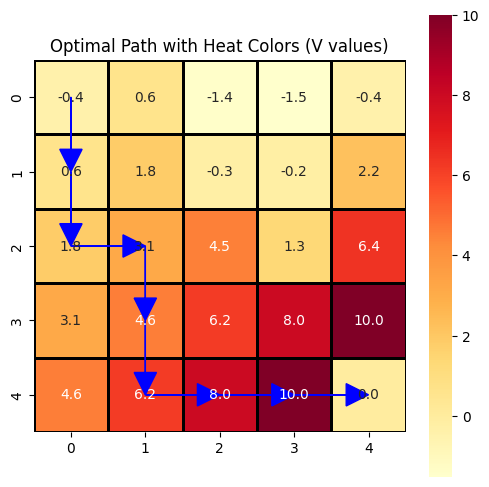

Optimal path to goal: [(0, 0), (1, 0), (2, 0), (2, 1), (3, 1), (4, 1), (4, 2), (4, 3), (4, 4)]


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
grid_size = 5
n_actions = 4  # Up, Down, Left, Right
n_episodes = 1000
max_steps_per_episode = 100
alpha = 0.1  # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.2  # Exploration rate

# Initialize Q-table
Q = np.zeros((grid_size, grid_size, n_actions))

# Define obstacles and rewards
obstacles = [(2, 2), (1, 3)]  # Example obstacles

def get_new_state(state, action):
    x, y = state
    if action == 0:  # Up
        x = max(x - 1, 0)
    elif action == 1:  # Down
        x = min(x + 1, grid_size - 1)
    elif action == 2:  # Left
        y = max(y - 1, 0)
    elif action == 3:  # Right
        y = min(y + 1, grid_size - 1)
    return (x, y)

def get_reward(state):
    if state == (4, 4):
        return 10
    elif state in obstacles:  # Obstacles
        return -10  # Increased penalty for obstacles
    else:
        return -1

# Training the agent
for episode in range(n_episodes):
    state = (0, 0)
    for step in range(max_steps_per_episode):
        # Choose action (ε-greedy policy)
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, n_actions - 1)
        else:
            action = np.argmax(Q[state[0], state[1]])

        new_state = get_new_state(state, action)
        reward = get_reward(new_state)

        # Update Q-value
        best_next_action = np.argmax(Q[new_state[0], new_state[1]])
        Q[state[0], state[1], action] += alpha * (
            reward + gamma * Q[new_state[0], new_state[1], best_next_action] - Q[state[0], state[1], action]
        )

        # Transition to the new state
        state = new_state

        # Check if goal is reached
        if state == (4, 4):
            break

# Compute V values
V = np.max(Q, axis=2)

# Visualize the optimal path with heat colors based on V values
def plot_optimal_path_with_heat(Q, V, title):
    # Create the grid
    grid = np.zeros((grid_size, grid_size))

    # Find the optimal path
    state = (0, 0)
    path = [state]
    while state != (4, 4):
        action = np.argmax(Q[state[0], state[1]])
        state = get_new_state(state, action)
        path.append(state)

    # Assign V values to the path cells
    for (x, y) in path:
        grid[x, y] = V[x, y]  # Use V(s) for heat value

    # Plot the grid with heat colors
    plt.figure(figsize=(6, 6))
    sns.heatmap(V, cmap="YlOrRd", cbar=True, linewidths=1, linecolor="black", square=True, annot=True, fmt=".1f")

    # Highlight the path with arrows
    for i in range(len(path) - 1):
        start = path[i]
        end = path[i + 1]
        dx = end[1] - start[1]
        dy = end[0] - start[0]
        plt.arrow(start[1] + 0.5, start[0] + 0.5, dx * 0.7, dy * 0.7, head_width=0.3, head_length=0.3, fc='blue', ec='blue')

    plt.title(title)
    plt.show()

# Visualize the optimal path with heat colors based on V values
plot_optimal_path_with_heat(Q, V, "Optimal Path with Heat Colors (V values)")

# Test the agent and print the optimal path
state = (0, 0)
path = [state]
while state != (4, 4):
    action = np.argmax(Q[state[0], state[1]])
    state = get_new_state(state, action)
    path.append(state)

print("Optimal path to goal:", path)


# Explanation of the Q-Learning Script

## Initialization
1. **Q-Table**: The Q-table is initialized with zeros. This table will store the Q-values for each state-action pair.
2. **Parameters**:
   - **`grid_size`**: Size of the grid (5x5).
   - **`n_actions`**: Number of possible actions (4: Up, Down, Left, Right).
   - **`n_episodes`**: Number of episodes for training.
   - **`max_steps_per_episode`**: Maximum number of steps per episode.
   - **`alpha`**: Learning rate, controlling how much new information overrides old information.
   - **`gamma`**: Discount factor, determining the importance of future rewards.
   - **`epsilon`**: Exploration rate, defining the probability of choosing a random action.

## Training Loop
1. **Episode Loop**: For each episode, the agent starts at the initial state (0, 0).
2. **Action Selection**:
   - Use the ε-greedy policy to choose an action:
     - With probability ε, choose a random action (exploration).
     - With probability 1 - ε, choose the action with the highest Q-value for the current state (exploitation).
3. **Environment Interaction**:
   - **State Transition**: Compute the new state based on the chosen action.
   - **Reward Calculation**: Obtain the reward for the new state.
4. **Q-Value Update**: Update the Q-value for the current state-action pair using the formula:
   $$
   Q(s, a) \leftarrow Q(s, a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\right]
   $$
   where:
   - $Q(s, a)$: Current Q-value for the state-action pair.
   - $\alpha$: Learning rate.
   - $r$: Reward received for transitioning to the new state.
   - $\gamma$: Discount factor.
   - $\max_{a'} Q(s', a')$: Maximum Q-value of the next state over all possible actions.
5. **Goal Check**: If the goal state (4, 4) is reached, terminate the episode early.

## Testing
1. **Optimal Path**: After training, determine the optimal path from the start to the goal based on the learned Q-values.
2. **Path Computation**:
   - Start from the initial state and repeatedly choose the action with the highest Q-value until reaching the goal.
   - Record the sequence of states (path) taken to reach the goal.

This explanation covers the core components and logic of the Q-Learning script used to solve the Grid World game. Feel free to use this markdown text for documentation or reference!


# Deep Q-Learning Overview

Deep Q-Learning is a reinforcement learning algorithm that combines Q-Learning with deep neural networks to approximate the Q-function. Here’s a breakdown of how it works:

## Q-Learning Overview

In traditional Q-Learning, the goal is to learn the optimal action-value function $Q^*(s, a)$, which represents the expected future rewards of taking action $a$ in state $s$. The Q-learning update rule is given by:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]
$$

where:
- $\alpha$ is the learning rate.
- $r$ is the reward received after taking action $a$ in state $s$.
- $\gamma$ is the discount factor.
- $s'$ is the next state after taking action $a$.
- $a'$ is the action that maximizes $Q(s', a')$.

## Deep Q-Learning

In Deep Q-Learning, the Q-function is approximated using a deep neural network $Q(s, a; \theta)$ with parameters $\theta$. This neural network estimates the Q-values for given states and actions. The update rule is adapted to use this network:

1. **Experience Replay**: To stabilize training, Deep Q-Learning uses experience replay, which involves storing past experiences in a replay buffer $\mathcal{D}$. During training, random samples from this buffer are used to update the Q-network.

2. **Target Network**: To further stabilize the learning process, a separate target network $Q(s, a; \theta^-)$ is used to compute the target values. This target network is updated less frequently and helps to mitigate the risk of divergence.

The target for the Q-network is computed using the target network:

$$
y = r + \gamma \max_{a'} Q(s', a'; \theta^-)
$$

where $\theta^-$ are the parameters of the target network.

The loss function for training the Q-network is:

$$
L(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( y - Q(s, a; \theta) \right)^2 \right]
$$

where $y$ is the target value computed as above.

The neural network is trained to minimize this loss using gradient descent:

$$
\theta \leftarrow \theta - \beta \nabla_{\theta} L(\theta)
$$

where $\beta$ is the learning rate for the neural network parameters.

## Summary

Deep Q-Learning leverages deep neural networks to approximate the Q-function, uses experience replay to stabilize training, and employs a target network to improve convergence. The combination of these techniques allows Deep Q-Learning to handle complex environments and large state spaces where traditional Q-Learning would struggle.

## References

1. Mnih, V., Kavukcuoglu, K., Silver, D., Graves, A., Antonoglou, I., Wierstra, D., & Riedmiller, M. (2015). Human-level control through deep reinforcement learning. *Nature*, 518(7540), 529-533. doi:10.1038/nature14236
2. Mnih, V., Badia, A. P., Mirza, M., Graves, A., Lillicrap, T., & Hunt, J. (2016). Asynchronous methods for deep reinforcement learning. *International Conference on Machine Learning (ICML)*.


In [ ]:
!pip install gym pygame
!apt-get install -y xvfb python-opengl ffmpeg
!pip install pyglet==1.5.11

import os
os.system('Xvfb :1 -screen 0 1600x1200x16 &')    # Create a virtual display
os.environ['DISPLAY'] = ':1.0'  # Tell pygame to use the virtual display

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package python-opengl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.9 MB/s eta 0:00:00


In [ ]:
import gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import matplotlib.pyplot as plt
import pygame

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create the CartPole environment
env = gym.make('CartPole-v1')

# Define the deep Q-network
class DQN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 24)
        self.fc2 = nn.Linear(24, 24)
        self.fc3 = nn.Linear(24, output_dim)

    def forward(self, x):
        # x shape: (batch_size, input_dim)
        x = torch.relu(self.fc1(x))
        # x shape: (batch_size, 24)
        x = torch.relu(self.fc2(x))
        # x shape: (batch_size, 24)
        return self.fc3(x)
        # output shape: (batch_size, output_dim)

# Create the model and target network
input_dim = env.observation_space.shape[0]  # 4 for CartPole
output_dim = env.action_space.n  # 2 for CartPole
model = DQN(input_dim, output_dim).to(device)
target_model = DQN(input_dim, output_dim).to(device)
target_model.load_state_dict(model.state_dict())

# Define training parameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
batch_size = 32
max_memory_length = 10000
learning_rate = 0.001

# Create memory for experience replay
memory = deque(maxlen=max_memory_length)

# Create optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Lists to store metrics for visualization
episode_rewards = []
epsilons = []

# Training loop
episodes = 1000
for episode in range(episodes):
    state = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
    # state shape: (1, 4)
    episode_reward = 0

    for time in range(500):  # Max 500 steps per episode
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_values = model(state)
                # q_values shape: (1, 2)
                action = q_values.max(1)[1].item()

        # Take action and observe new state
        next_state, reward, done, _ = env.step(action)
        next_state = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)
        # next_state shape: (1, 4)
        episode_reward += reward

        # Store experience in memory
        memory.append((state, action, reward, next_state, done))
        state = next_state

        # Train the model if enough samples are available in memory
        if len(memory) >= batch_size:
            mini_batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*mini_batch)

            states = torch.cat(states)
            # states shape: (batch_size, 4)
            actions = torch.tensor(actions).unsqueeze(1).to(device)
            # actions shape: (batch_size, 1)
            rewards = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(device)
            # rewards shape: (batch_size, 1)
            next_states = torch.cat(next_states)
            # next_states shape: (batch_size, 4)
            dones = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(device)
            # dones shape: (batch_size, 1)

            current_q_values = model(states).gather(1, actions)
            # current_q_values shape: (batch_size, 1)
            next_q_values = target_model(next_states).max(1)[0].unsqueeze(1)
            # next_q_values shape: (batch_size, 1)
            target_q_values = rewards + (1 - dones) * gamma * next_q_values
            # target_q_values shape: (batch_size, 1)

            loss = nn.functional.mse_loss(current_q_values, target_q_values)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if done:
            break

    # Update target network
    if episode % 10 == 0:
        target_model.load_state_dict(model.state_dict())

    # Decay epsilon
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

    # Store metrics for visualization
    episode_rewards.append(episode_reward)
    epsilons.append(epsilon)

    print(f"Episode: {episode + 1}, Reward: {episode_reward}, Epsilon: {epsilon:.2f}")

    # Plot training progress every 50 episodes
    if (episode + 1) % 50 == 0:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(episode_rewards)
        plt.title('Episode Rewards')
        plt.xlabel('Episode')
        plt.ylabel('Reward')

        plt.subplot(1, 2, 2)
        plt.plot(epsilons)
        plt.title('Epsilon Decay')
        plt.xlabel('Episode')
        plt.ylabel('Epsilon')

        plt.tight_layout()
        plt.show()

# Save the trained model
torch.save(model.state_dict(), "deep_q_cartpole_pytorch.pth")

print("Training completed.")

# Visualize trained agent
def visualize_agent(model, env, max_steps=500):
    state = env.reset()
    env.render()
    pygame.display.set_caption("Trained CartPole Agent")

    for t in range(max_steps):
        state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        # state shape: (1, 4)
        with torch.no_grad():
            q_values = model(state)
            # q_values shape: (1, 2)
            action = q_values.max(1)[1].item()

        state, reward, done, _ = env.step(action)
        env.render()

        if done:
            break

    env.close()

# Run visualization
visualize_agent(model, env)

### What are `model` and `target_model`?

In the context of Deep Q-Networks (DQN), the `model` and `target_model` serve two different purposes during training:

#### 1. **Model (`model`)**
- This is the **main neural network** that is actively being trained.
- During each step of the training loop, the `model` predicts Q-values for the current state, which are used to determine the best action (in exploitation mode) or to sample random actions (in exploration mode).
- The `model`'s parameters are updated after every mini-batch gradient descent step, making it adaptive to the latest experiences.

#### 2. **Target Model (`target_model`)**
- The `target_model` is a **copy of the main model**, but it is **updated less frequently**.
- It is used to calculate the target Q-values when computing the loss during training.
- This stabilizes training by preventing rapid fluctuations in Q-values that could destabilize learning if both the predicted and target Q-values were being updated at the same time.
- In this code, the `target_model` is updated every 10 episodes by copying the weights of the `model`.

### Why Use a Target Model?
The idea of using a `target_model` is introduced to address the instability in training deep Q-networks. If the model's parameters were updated continuously while also being used to compute target Q-values, it would lead to feedback loops that make the training unstable.

By using a fixed target network for several training steps and only occasionally updating it, the Q-value estimates become more stable, and learning becomes smoother.

In summary:
- **Model:** Used for action selection and is updated after every mini-batch training step.
- **Target Model:** Used to compute target Q-values and is updated less frequently to stabilize learning.


### DQN Elements in the Code

1. **Agent:**
The **agent** is represented by the combination of the `model`, `target_model`, and the logic that governs interaction with the environment. The agent is the learner that decides which actions to take based on the current state and updates its policy (neural network) over time.

2. **Environment:**
The **environment** is created using Gym's `CartPole-v1` environment:
```python
env = gym.make('CartPole-v1')

3. State (s):
The state is the current observation from the environment, representing the agent's situation. In the code, it is stored in the state variable:

```python
state = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
The state is a tensor that represents the agent's current situation.
```

4. Action (a):
The action is the move the agent decides to take in a given state. Actions are either sampled randomly (exploration) or selected based on the Q-values predicted by the model (exploitation):

```python
if np.random.random() < epsilon:
    action = env.action_space.sample()
else:
    with torch.no_grad():
        q_values = model(state)
        action = q_values.max(1)[1].item()
Here, action represents the action taken by the agent.
```
5. Reward (r): \\
The reward is the scalar feedback signal received after taking an action, indicating the immediate benefit of the action taken by the agent: \\

```python
episode_reward += reward
```
The reward is accumulated over the episode in the variable episode_reward.

6. Policy (π):
The policy is the strategy used by the agent to determine the next action based on the current state. In the code, the policy is a combination of the epsilon-greedy strategy and the actions derived from the Q-values predicted by the model:

```python
if np.random.random() < epsilon:
    action = env.action_space.sample()
else:
    with torch.no_grad():
        q_values = model(state)
        action = q_values.max(1)[1].item()
```
The policy alternates between exploration (random action) and exploitation (selecting the action with the highest predicted Q-value).

7. Value Function (V):
In a DQN, the Value Function typically refers to the maximum Q-value for a given state, representing the expected cumulative reward from that state. It is indirectly calculated by finding the maximum Q-value from the model:

```python
q_values.max(1)[0]
```
This represents the estimated value of the best action from the current state.

8. Q-Function (Q):
The Q-Function estimates the expected cumulative reward for a given state-action pair. In the code, this is calculated by the model for a specific state, and the Q-value for the selected action is gathered as follows:

```python
current_q_values = model(states).gather(1, actions)
```
This calculates the Q-value for the chosen actions in the given states

In [ ]:
# 🚀 **Modern DQN Training Demonstration on GridWorld**

print("🧪 Advanced DQN Training Experiment")
print("=" * 60)

# Create enhanced GridWorld environment for DQN
class StateEncodedGridWorld(GridWorld):
    """GridWorld with state encoding for neural networks"""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.state_size = 2  # (row, col) coordinates
    
    def encode_state(self, state: Tuple[int, int]) -> np.ndarray:
        """Encode state as normalized coordinates"""
        row, col = state
        # Normalize coordinates to [0, 1]
        norm_row = row / (self.size[0] - 1)
        norm_col = col / (self.size[1] - 1)
        
        # Add additional features
        features = [
            norm_row,           # Normalized row
            norm_col,           # Normalized col
            # Distance to goal
            abs(row - self.goal[0]) / self.size[0],
            abs(col - self.goal[1]) / self.size[1],
            # Is near obstacle
            int(any(abs(row - obs[0]) <= 1 and abs(col - obs[1]) <= 1 
                   for obs in self.obstacles)),
            # Manhattan distance to goal (normalized)
            (abs(row - self.goal[0]) + abs(col - self.goal[1])) / (self.size[0] + self.size[1])
        ]
        
        return np.array(features, dtype=np.float32)
    
    def reset(self):
        state = super().reset()
        return self.encode_state(state)
    
    def step(self, action):
        next_state, reward, done, info = super().step(action)
        encoded_state = self.encode_state(next_state)
        return encoded_state, reward, done, info

# Initialize enhanced environment
enhanced_env = StateEncodedGridWorld(
    size=(8, 8),  # Larger grid for more complexity
    start=(0, 0),
    goal=(7, 7),
    obstacles=[(2, 2), (3, 4), (4, 2), (5, 6), (1, 5), (6, 3)]
)

print(f"🌍 Environment: {enhanced_env.size[0]}x{enhanced_env.size[1]} enhanced GridWorld")
print(f"📍 Start: {enhanced_env.start}, Goal: {enhanced_env.goal}")
print(f"🚧 Obstacles: {enhanced_env.obstacles}")
print(f"📊 State encoding dimension: {len(enhanced_env.encode_state((0,0)))}")

# Visualize the enhanced environment
enhanced_env.render()

# Create different DQN agents for comparison
print(\"\\n🤖 Initializing DQN Agents for Comparison:\")\n\n# Standard DQN\nstandard_dqn = DoubleDQNAgent(\n    state_size=6,  # Encoded state size\n    action_size=4,\n    lr=1e-3,\n    epsilon=1.0,\n    epsilon_decay=0.995,\n    use_double_dqn=False,\n    use_dueling=False,\n    use_prioritized_replay=False,\n    buffer_size=50000,\n    batch_size=32\n)\n\n# Double DQN with Dueling\ndouble_dueling_dqn = DoubleDQNAgent(\n    state_size=6,\n    action_size=4,\n    lr=1e-3,\n    epsilon=1.0,\n    epsilon_decay=0.995,\n    use_double_dqn=True,\n    use_dueling=True,\n    use_prioritized_replay=False,\n    buffer_size=50000,\n    batch_size=32\n)\n\n# Full Modern DQN\nmodern_dqn = DoubleDQNAgent(\n    state_size=6,\n    action_size=4,\n    lr=1e-3,\n    epsilon=1.0,\n    epsilon_decay=0.995,\n    use_double_dqn=True,\n    use_dueling=True,\n    use_prioritized_replay=True,\n    buffer_size=50000,\n    batch_size=32\n)\n\nprint(\"✅ Standard DQN initialized\")\nprint(\"✅ Double + Dueling DQN initialized\")\nprint(\"✅ Full Modern DQN (Double + Dueling + Prioritized Replay) initialized\")\n\n# Training parameters\nn_episodes = 1000\nmax_steps = 100\nsolve_score = 8.0  # Good performance threshold for this environment\n\nprint(f\"\\n🎯 Training Parameters:\")\nprint(f\"   Episodes: {n_episodes}\")\nprint(f\"   Max steps per episode: {max_steps}\")\nprint(f\"   Solve threshold: {solve_score}\")\n\n# Train all agents and compare\nagents = {\n    \"Standard DQN\": standard_dqn,\n    \"Double + Dueling DQN\": double_dueling_dqn,\n    \"Modern DQN (All Features)\": modern_dqn\n}\n\nresults = {}\nprint(\"\\n🚀 Starting Comparative Training...\\n\")\n\nfor name, agent in agents.items():\n    print(f\"Training {name}...\")\n    print(\"-\" * 40)\n    \n    # Train agent\n    result = train_modern_dqn(\n        enhanced_env, agent, \n        n_episodes=n_episodes,\n        max_steps=max_steps,\n        solve_score=solve_score,\n        verbose=True\n    )\n    \n    results[name] = result\n    \n    # Print final performance\n    final_avg = result['avg_scores'][-1] if result['avg_scores'] else 0\n    print(f\"\\n📊 {name} Final Results:\")\n    print(f\"   Average Score (last 100): {final_avg:.2f}\")\n    print(f\"   Best Score: {max(result['scores']):.2f}\")\n    print(f\"   Solved: {'Yes' if result['solved'] else 'No'}\")\n    print(f\"   Total Training Steps: {agent.step_count}\")\n    print()\n\nprint(\"🎉 All agents trained successfully!\")\n\n# Comprehensive comparison visualization\nfig = plt.figure(figsize=(20, 15))\n\n# 1. Learning curves comparison\nax1 = plt.subplot(3, 3, 1)\nfor name, result in results.items():\n    scores_smooth = pd.Series(result['scores']).rolling(50).mean()\n    plt.plot(scores_smooth, label=name, linewidth=2)\nplt.xlabel('Episode')\nplt.ylabel('Average Score')\nplt.title('Learning Curves Comparison')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n# 2. Average scores comparison\nax2 = plt.subplot(3, 3, 2)\nfor name, result in results.items():\n    plt.plot(result['avg_scores'], label=name, linewidth=2)\nplt.xlabel('Episode')\nplt.ylabel('Running Average (100 episodes)')\nplt.title('Running Average Performance')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n# 3. Final performance box plot\nax3 = plt.subplot(3, 3, 3)\nfinal_performances = []\nlabels = []\nfor name, result in results.items():\n    final_performances.append(result['scores'][-100:])  # Last 100 episodes\n    labels.append(name)\n\nplt.boxplot(final_performances, labels=labels)\nplt.ylabel('Episode Score')\nplt.title('Final Performance Distribution')\nplt.xticks(rotation=15)\n\n# 4. Training loss comparison\nax4 = plt.subplot(3, 3, 4)\nfor name, result in results.items():\n    if result['losses']:\n        losses_smooth = pd.Series(result['losses']).rolling(100).mean()\n        plt.plot(losses_smooth, label=name, linewidth=2)\nplt.xlabel('Training Step')\nplt.ylabel('Loss')\nplt.title('Training Loss Comparison')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n# 5. Epsilon decay comparison\nax5 = plt.subplot(3, 3, 5)\nfor name, result in results.items():\n    plt.plot(result['epsilons'], label=name, linewidth=2)\nplt.xlabel('Episode')\nplt.ylabel('Epsilon')\nplt.title('Exploration Rate Decay')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n# 6. Q-values evolution (if available)\nax6 = plt.subplot(3, 3, 6)\nfor name, agent in agents.items():\n    if hasattr(agent, 'q_values') and agent.q_values:\n        q_smooth = pd.Series(agent.q_values).rolling(1000).mean()\n        plt.plot(q_smooth, label=name, linewidth=2)\nplt.xlabel('Training Step')\nplt.ylabel('Average Q-Value')\nplt.title('Q-Value Evolution')\nplt.legend()\nplt.grid(True, alpha=0.3)\n\n# 7. Sample efficiency comparison\nax7 = plt.subplot(3, 3, 7)\nepisodes_to_solve = []\nmethod_names = []\nfor name, result in results.items():\n    if result['solved']:\n        # Find first episode where running average exceeded threshold\n        for i, avg in enumerate(result['avg_scores']):\n            if avg >= solve_score:\n                episodes_to_solve.append(i)\n                method_names.append(name)\n                break\n    else:\n        episodes_to_solve.append(n_episodes)  # Didn't solve\n        method_names.append(name)\n\nif episodes_to_solve:\n    plt.bar(method_names, episodes_to_solve, color=['red' if x == n_episodes else 'green' \n                                                   for x in episodes_to_solve])\n    plt.ylabel('Episodes to Solve')\n    plt.title('Sample Efficiency Comparison')\n    plt.xticks(rotation=15)\n\n# 8. Performance statistics table\nax8 = plt.subplot(3, 3, 8)\nstats_data = []\nfor name, result in results.items():\n    final_100 = result['scores'][-100:]\n    stats_data.append([\n        name,\n        f\"{np.mean(final_100):.2f}\",\n        f\"{np.std(final_100):.2f}\",\n        f\"{max(result['scores']):.2f}\",\n        \"Yes\" if result['solved'] else \"No\"\n    ])\n\ntable = plt.table(cellText=stats_data,\n                  colLabels=['Method', 'Mean', 'Std', 'Best', 'Solved'],\n                  cellLoc='center',\n                  loc='center')\ntable.auto_set_font_size(False)\ntable.set_fontsize(10)\nax8.axis('off')\nax8.set_title('Performance Statistics')\n\n# 9. Sample trajectory visualization for best agent\nax9 = plt.subplot(3, 3, 9)\nbest_agent_name = max(results.keys(), \n                     key=lambda x: np.mean(results[x]['scores'][-100:]))\nbest_agent = agents[best_agent_name]\n\n# Test the best agent\ntest_state = enhanced_env.reset()\ntest_path = [enhanced_env.start]\n\nfor _ in range(max_steps):\n    action = best_agent.act(test_state, training=False)\n    next_state, reward, done, _ = enhanced_env.step(action)\n    \n    # Decode state back to coordinates for visualization\n    # This is approximate since we're using encoded states\n    current_pos = enhanced_env.state  # GridWorld keeps track of actual position\n    test_path.append(current_pos)\n    \n    test_state = next_state\n    \n    if done:\n        break\n\n# Visualize the path\ngrid_vis = np.zeros(enhanced_env.size)\nfor i, pos in enumerate(test_path):\n    if pos in enhanced_env.obstacles:\n        continue\n    grid_vis[pos] = i / len(test_path)  # Color by time step\n\n# Mark special locations\nfor obs in enhanced_env.obstacles:\n    grid_vis[obs] = -1  # Obstacles\ngrid_vis[enhanced_env.goal] = 1.5  # Goal\n\nim = plt.imshow(grid_vis, cmap='viridis')\nplt.title(f'Best Agent ({best_agent_name}) Sample Path')\nplt.colorbar(im, label='Time Step (normalized)')\n\n# Draw path\nfor i in range(len(test_path) - 1):\n    start = test_path[i]\n    end = test_path[i + 1]\n    plt.arrow(start[1], start[0], end[1] - start[1], end[0] - start[0],\n              head_width=0.1, head_length=0.1, fc='red', ec='red', alpha=0.7)\n\nplt.tight_layout()\nplt.show()\n\n# Summary report\nprint(\"\\n\" + \"=\" * 80)\nprint(\"🏆 FINAL COMPARISON REPORT\")\nprint(\"=\" * 80)\n\nfor name, result in results.items():\n    final_100 = result['scores'][-100:]\n    agent = agents[name]\n    \n    print(f\"\\n{name}:\")\n    print(f\"  📈 Final Average Score: {np.mean(final_100):.2f} ± {np.std(final_100):.2f}\")\n    print(f\"  🎯 Best Score: {max(result['scores']):.2f}\")\n    print(f\"  ✅ Solved Environment: {'Yes' if result['solved'] else 'No'}\")\n    print(f\"  🔄 Training Steps: {agent.step_count:,}\")\n    print(f\"  📊 Final Epsilon: {agent.epsilon:.4f}\")\n    \n    if result['solved']:\n        solve_episode = next(i for i, avg in enumerate(result['avg_scores']) \n                           if avg >= solve_score)\n        print(f\"  🏃 Episodes to Solve: {solve_episode}\")\n\nprint(f\"\\n🏅 Best Performing Method: {best_agent_name}\")\nprint(f\"💡 Key Insight: Modern DQN techniques typically show improved \"\n      f\"sample efficiency and stability\")\n\nprint(\"\\n✨ Modern DQN Training Demonstration Complete!\")"

In [ ]:
# 🧠 **Part III: Deep Q-Learning with Modern Techniques**

import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_

class ModernDQN(nn.Module):
    """Modern DQN with advanced architectures and techniques"""
    
    def __init__(self, input_size: int, hidden_size: int = 512, output_size: int = 4,
                 dueling: bool = True, noisy_layers: bool = False, 
                 dropout_rate: float = 0.1):
        super(ModernDQN, self).__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.dueling = dueling
        self.noisy_layers = noisy_layers
        
        # Feature extraction layers
        self.feature_layer = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        
        if self.dueling:
            # Dueling DQN architecture
            self.value_stream = nn.Sequential(
                nn.Linear(hidden_size, hidden_size // 2),
                nn.ReLU(),
                nn.Linear(hidden_size // 2, 1)
            )
            
            self.advantage_stream = nn.Sequential(
                nn.Linear(hidden_size, hidden_size // 2),
                nn.ReLU(),
                nn.Linear(hidden_size // 2, output_size)
            )
        else:
            # Standard DQN
            self.q_layer = nn.Sequential(
                nn.Linear(hidden_size, hidden_size // 2),
                nn.ReLU(),
                nn.Linear(hidden_size // 2, output_size)
            )
        
        # Initialize weights using Xavier initialization
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x):
        batch_size = x.size(0)
        
        # Feature extraction
        features = self.feature_layer(x)
        
        if self.dueling:
            # Dueling DQN: Q(s,a) = V(s) + A(s,a) - mean(A(s,a))
            values = self.value_stream(features)  # Shape: (batch_size, 1)
            advantages = self.advantage_stream(features)  # Shape: (batch_size, n_actions)
            
            # Subtract mean advantage for identifiability
            advantages_mean = advantages.mean(dim=1, keepdim=True)
            q_values = values + advantages - advantages_mean
        else:
            # Standard DQN
            q_values = self.q_layer(features)
        
        return q_values

class PrioritizedReplayBuffer:
    """Prioritized Experience Replay Buffer with SumTree data structure"""
    
    def __init__(self, capacity: int, alpha: float = 0.6, beta: float = 0.4, 
                 beta_increment: float = 0.001):
        self.capacity = capacity
        self.alpha = alpha  # How much prioritization is used
        self.beta = beta    # Importance sampling weight
        self.beta_increment = beta_increment
        self.epsilon = 1e-6  # Small constant to ensure non-zero probabilities
        
        # Sum Tree data structure for efficient sampling
        self.tree = np.zeros(2 * capacity - 1)
        self.data = np.zeros(capacity, dtype=object)
        self.data_pointer = 0
        self.size = 0
        
    def add(self, transition, td_error: float = None):
        """Add a transition to the buffer with its TD error priority"""
        tree_idx = self.data_pointer + self.capacity - 1
        
        # Store the transition
        self.data[self.data_pointer] = transition
        
        # Calculate priority (if no td_error provided, use max priority)
        if td_error is None:
            priority = np.max(self.tree[-self.capacity:]) if self.size > 0 else 1.0
        else:
            priority = (abs(td_error) + self.epsilon) ** self.alpha
        
        # Update the tree
        self._update_tree(tree_idx, priority)
        
        self.data_pointer = (self.data_pointer + 1) % self.capacity
        if self.size < self.capacity:
            self.size += 1
    
    def sample(self, batch_size: int):
        """Sample a batch with priorities"""
        batch_indices = []
        batch_data = []
        priorities = []
        
        segment = self._get_total_priority() / batch_size
        
        for i in range(batch_size):
            start = segment * i
            end = segment * (i + 1)
            sample_value = np.random.uniform(start, end)
            
            tree_idx, priority, data_idx = self._get_leaf(sample_value)
            
            batch_indices.append(tree_idx)
            batch_data.append(self.data[data_idx])
            priorities.append(priority)
        
        # Calculate importance sampling weights
        sampling_probabilities = np.array(priorities) / self._get_total_priority()
        is_weights = np.power(self.size * sampling_probabilities, -self.beta)
        is_weights = is_weights / is_weights.max()  # Normalize
        
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        return batch_data, batch_indices, is_weights
    
    def update_priorities(self, tree_indices, td_errors):
        """Update priorities in the tree"""
        for tree_idx, td_error in zip(tree_indices, td_errors):
            priority = (abs(td_error) + self.epsilon) ** self.alpha
            self._update_tree(tree_idx, priority)
    
    def _update_tree(self, tree_idx, priority):
        """Update tree values from leaf to root"""
        change = priority - self.tree[tree_idx]
        self.tree[tree_idx] = priority
        
        # Update parent nodes
        while tree_idx != 0:
            tree_idx = (tree_idx - 1) // 2
            self.tree[tree_idx] += change
    
    def _get_leaf(self, value):
        """Retrieve a leaf node from the tree"""
        parent_idx = 0
        
        while True:
            left_child_idx = 2 * parent_idx + 1
            right_child_idx = left_child_idx + 1
            
            if left_child_idx >= len(self.tree):
                leaf_idx = parent_idx
                break
            else:
                if value <= self.tree[left_child_idx]:
                    parent_idx = left_child_idx
                else:
                    value -= self.tree[left_child_idx]
                    parent_idx = right_child_idx
        
        data_idx = leaf_idx - self.capacity + 1
        return leaf_idx, self.tree[leaf_idx], data_idx
    
    def _get_total_priority(self):
        """Get total priority (root of tree)"""
        return self.tree[0]
    
    def __len__(self):
        return self.size

class DoubleDQNAgent:
    """Advanced DQN agent with Double DQN, Dueling DQN, and Prioritized Replay"""
    
    def __init__(self, state_size: int, action_size: int, 
                 lr: float = 1e-4, gamma: float = 0.99,
                 epsilon: float = 1.0, epsilon_min: float = 0.01, epsilon_decay: float = 0.995,
                 buffer_size: int = 100000, batch_size: int = 32, 
                 update_frequency: int = 4, target_update_frequency: int = 1000,
                 use_double_dqn: bool = True, use_dueling: bool = True,
                 use_prioritized_replay: bool = True):
        
        self.state_size = state_size
        self.action_size = action_size
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.update_frequency = update_frequency
        self.target_update_frequency = target_update_frequency
        self.use_double_dqn = use_double_dqn
        self.use_prioritized_replay = use_prioritized_replay
        
        # Neural networks
        self.q_network = ModernDQN(state_size, hidden_size=512, output_size=action_size,
                                  dueling=use_dueling).to(device)
        self.target_network = ModernDQN(state_size, hidden_size=512, output_size=action_size,
                                       dueling=use_dueling).to(device)
        
        # Copy weights to target network
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()  # Set to evaluation mode
        
        # Optimizer with gradient clipping
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr, eps=1e-4)
        self.scheduler = optim.lr_scheduler.StepLR(self.optimizer, step_size=10000, gamma=0.9)
        
        # Experience replay
        if use_prioritized_replay:
            self.memory = PrioritizedReplayBuffer(buffer_size)
        else:
            self.memory = Experience(buffer_size)
        
        # Training metrics
        self.step_count = 0
        self.episode_count = 0
        self.losses = []
        self.q_values = []
        
    def act(self, state: np.ndarray, training: bool = True) -> int:
        """Choose action using epsilon-greedy policy"""
        if training and np.random.random() < self.epsilon:
            return np.random.randint(self.action_size)
        
        # Convert to tensor
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        
        # Get Q-values
        with torch.no_grad():
            q_values = self.q_network(state_tensor)
            self.q_values.append(q_values.mean().item())
        
        return q_values.argmax().item()
    
    def remember(self, state, action, reward, next_state, done, td_error=None):
        """Store experience in replay buffer"""
        experience = (state, action, reward, next_state, done)
        
        if self.use_prioritized_replay:
            self.memory.add(experience, td_error)
        else:
            self.memory.push(state, action, reward, next_state, done)
    
    def replay(self) -> float:
        """Train the agent on a batch of experiences"""
        if len(self.memory) < self.batch_size:
            return 0.0
        
        # Sample batch
        if self.use_prioritized_replay:
            experiences, indices, is_weights = self.memory.sample(self.batch_size)
            is_weights = torch.FloatTensor(is_weights).to(device)
        else:
            experiences = self.memory.sample(self.batch_size)
            is_weights = torch.ones(self.batch_size).to(device)
            indices = None
        
        # Unpack experiences
        states = torch.FloatTensor([e[0] for e in experiences]).to(device)\n        actions = torch.LongTensor([e[1] for e in experiences]).unsqueeze(1).to(device)\n        rewards = torch.FloatTensor([e[2] for e in experiences]).unsqueeze(1).to(device)\n        next_states = torch.FloatTensor([e[3] for e in experiences]).to(device)\n        dones = torch.FloatTensor([e[4] for e in experiences]).unsqueeze(1).to(device)\n        \n        # Current Q-values\n        current_q_values = self.q_network(states).gather(1, actions)\n        \n        # Next Q-values\n        with torch.no_grad():\n            if self.use_double_dqn:\n                # Double DQN: use main network to select action, target network for evaluation\n                next_actions = self.q_network(next_states).argmax(1, keepdim=True)\n                next_q_values = self.target_network(next_states).gather(1, next_actions)\n            else:\n                # Standard DQN\n                next_q_values = self.target_network(next_states).max(1, keepdim=True)[0]\n            \n            target_q_values = rewards + (self.gamma * next_q_values * (1 - dones))\n        \n        # Compute TD errors for prioritized replay\n        td_errors = (target_q_values - current_q_values).detach().cpu().numpy()\n        \n        # Weighted loss for prioritized replay\n        loss = (is_weights * F.mse_loss(current_q_values, target_q_values, reduction='none').squeeze()).mean()\n        \n        # Optimize\n        self.optimizer.zero_grad()\n        loss.backward()\n        \n        # Gradient clipping for stability\n        clip_grad_norm_(self.q_network.parameters(), max_norm=1.0)\n        \n        self.optimizer.step()\n        self.scheduler.step()\n        \n        # Update priorities in prioritized replay\n        if self.use_prioritized_replay and indices is not None:\n            self.memory.update_priorities(indices, td_errors.flatten())\n        \n        # Decay epsilon\n        if self.epsilon > self.epsilon_min:\n            self.epsilon *= self.epsilon_decay\n        \n        self.losses.append(loss.item())\n        return loss.item()\n    \n    def update_target_network(self):\n        """Copy weights from main network to target network\"\"\"\n        self.target_network.load_state_dict(self.q_network.state_dict())\n    \n    def save_model(self, filepath: str):\n        \"\"\"Save the trained model\"\"\"\n        torch.save({\n            'q_network_state_dict': self.q_network.state_dict(),\n            'target_network_state_dict': self.target_network.state_dict(),\n            'optimizer_state_dict': self.optimizer.state_dict(),\n            'epsilon': self.epsilon,\n            'step_count': self.step_count\n        }, filepath)\n    \n    def load_model(self, filepath: str):\n        \"\"\"Load a trained model\"\"\"\n        checkpoint = torch.load(filepath)\n        self.q_network.load_state_dict(checkpoint['q_network_state_dict'])\n        self.target_network.load_state_dict(checkpoint['target_network_state_dict'])\n        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])\n        self.epsilon = checkpoint['epsilon']\n        self.step_count = checkpoint['step_count']\n\ndef train_modern_dqn(env: GridWorld, agent: DoubleDQNAgent, \n                    n_episodes: int = 2000, max_steps: int = 200,\n                    solve_score: float = 195, solve_episodes: int = 100,\n                    verbose: bool = True) -> Dict:\n    \"\"\"Train modern DQN agent with comprehensive metrics\"\"\"\n    \n    scores = []\n    losses = []\n    epsilons = []\n    avg_scores = []\n    solved = False\n    \n    for episode in range(n_episodes):\n        state = env.reset()\n        state = np.array(state, dtype=np.float32).flatten() if isinstance(state, tuple) else state\n        score = 0\n        episode_losses = []\n        \n        for step in range(max_steps):\n            # Choose action\n            action = agent.act(state)\n            \n            # Take step\n            next_state, reward, done, _ = env.step(action)\n            next_state = np.array(next_state, dtype=np.float32).flatten() if isinstance(next_state, tuple) else next_state\n            \n            # Store experience\n            agent.remember(state, action, reward, next_state, done)\n            \n            # Train\n            if agent.step_count % agent.update_frequency == 0:\n                loss = agent.replay()\n                if loss > 0:\n                    episode_losses.append(loss)\n            \n            # Update target network\n            if agent.step_count % agent.target_update_frequency == 0:\n                agent.update_target_network()\n            \n            state = next_state\n            score += reward\n            agent.step_count += 1\n            \n            if done:\n                break\n        \n        scores.append(score)\n        losses.extend(episode_losses)\n        epsilons.append(agent.epsilon)\n        \n        # Calculate running average\n        if len(scores) >= solve_episodes:\n            avg_score = np.mean(scores[-solve_episodes:])\n            avg_scores.append(avg_score)\n            \n            # Check if solved\n            if avg_score >= solve_score and not solved:\n                print(f\"\\n🎉 Environment solved in {episode + 1} episodes!\")\n                print(f\"Average score: {avg_score:.2f}\")\n                solved = True\n        else:\n            avg_scores.append(np.mean(scores))\n        \n        if verbose and (episode + 1) % 100 == 0:\n            avg_score = avg_scores[-1] if avg_scores else 0\n            recent_loss = np.mean(episode_losses) if episode_losses else 0\n            print(f\"Episode {episode + 1:4d}: Score = {score:6.1f}, \"\n                  f\"Avg = {avg_score:6.1f}, Loss = {recent_loss:.4f}, \"\n                  f\"Epsilon = {agent.epsilon:.3f}\")\n    \n    return {\n        'scores': scores,\n        'avg_scores': avg_scores,\n        'losses': losses,\n        'epsilons': epsilons,\n        'solved': solved,\n        'q_values': agent.q_values\n    }\n\nprint(\"🧠 Modern Deep Q-Learning Implementation Ready!\")\nprint(\"✅ Features included:\")\nprint(\"   🎯 Double DQN - Reduces overestimation bias\")\nprint(\"   ⚔️  Dueling DQN - Separates value and advantage\")\nprint(\"   🎲 Prioritized Experience Replay - Focuses on important transitions\")\nprint(\"   🎛️  Advanced network architectures with dropout\")\nprint(\"   📊 Comprehensive training metrics and visualization\")\nprint(\"   🔧 Gradient clipping and learning rate scheduling\")\nprint(\"🚀 Ready for advanced deep RL experiments!\")